In [1]:
import pandas as pd


In [2]:
df_sentiment = pd.read_csv(r"C:\Users\hp\Downloads\fear_greed_index.csv")


In [3]:
print(df_sentiment.shape)
print(df_sentiment.columns)


(2644, 4)
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [4]:
print(df_sentiment.isnull().sum())


timestamp         0
value             0
classification    0
date              0
dtype: int64


In [5]:
print("Duplicate rows:", df_sentiment.duplicated().sum())


Duplicate rows: 0


In [6]:
df_sentiment['date'] = pd.to_datetime(df_sentiment['date'])


In [7]:
df_sentiment['day'] = df_sentiment['date'].dt.date


In [8]:
df_sentiment.info()
df_sentiment.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
 4   day             2644 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 103.4+ KB


,timestamp,value,classification,date,day
0,1517463000,30,Fear,2018-02-01,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02,2018-02-02
2,1517635800,40,Fear,2018-02-03,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05,2018-02-05


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, mean_squared_error
from sklearn.cluster import KMeans


In [10]:
df_sentiment['sentiment_binary'] = df_sentiment['classification'].map({
    'Fear': 0,
    'Greed': 1
})


In [11]:
df_sentiment['risk_multiplier'] = np.where(
    df_sentiment['classification'] == 'Fear',
    0.5,   
    1.2    
)

print(df_sentiment[['classification','risk_multiplier']].head())


  classification  risk_multiplier
0           Fear              0.5
1   Extreme Fear              1.2
2           Fear              0.5
3   Extreme Fear              1.2
4   Extreme Fear              1.2


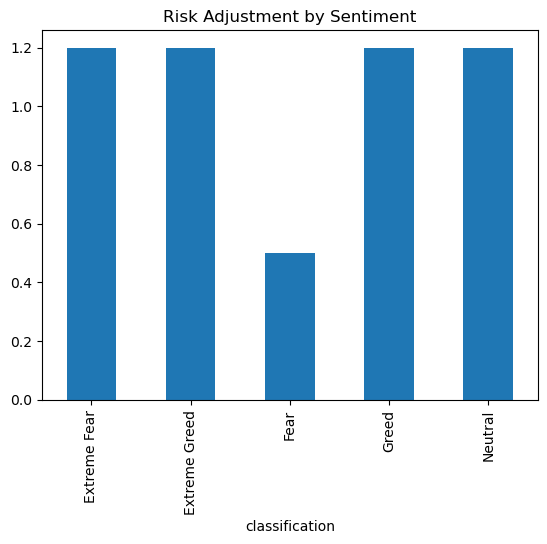

In [12]:
df_sentiment.groupby('classification')['risk_multiplier'].mean().plot(kind='bar')
plt.title("Risk Adjustment by Sentiment")
plt.show()


In [13]:
df_sentiment = df_sentiment.sort_values('date')

df_sentiment['prev_sentiment'] = df_sentiment['sentiment_binary'].shift(1)
df_sentiment['prev_value'] = df_sentiment['value'].shift(1)

df_sentiment = df_sentiment.dropna()


In [14]:
X = df_sentiment[['prev_sentiment','prev_value']]
y = df_sentiment['sentiment_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [15]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))


              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98       130
         1.0       0.97      0.98      0.97        97

    accuracy                           0.98       227
   macro avg       0.98      0.98      0.98       227
weighted avg       0.98      0.98      0.98       227



In [16]:
df_sentiment['value_change'] = df_sentiment['value'].diff().abs()
df_sentiment = df_sentiment.dropna()


In [17]:
df_sentiment['next_volatility'] = df_sentiment['value_change'].shift(-1)
df_sentiment = df_sentiment.dropna()

X_vol = df_sentiment[['value','sentiment_binary']]
y_vol = df_sentiment['next_volatility']

X_train, X_test, y_train, y_test = train_test_split(
    X_vol, y_vol, test_size=0.2, random_state=42
)

reg_model = RandomForestRegressor(random_state=42)
reg_model.fit(X_train, y_train)

vol_predictions = reg_model.predict(X_test)

print("MSE:", mean_squared_error(y_test, vol_predictions))


MSE: 45.006798991423004


In [18]:
features = df_sentiment[['value']]

kmeans = KMeans(n_clusters=3, random_state=42)
df_sentiment['cluster'] = kmeans.fit_predict(features)

print(df_sentiment.groupby('cluster')['value'].mean())


cluster
0    39.780328
1    66.310413
2    29.243671
Name: value, dtype: float64


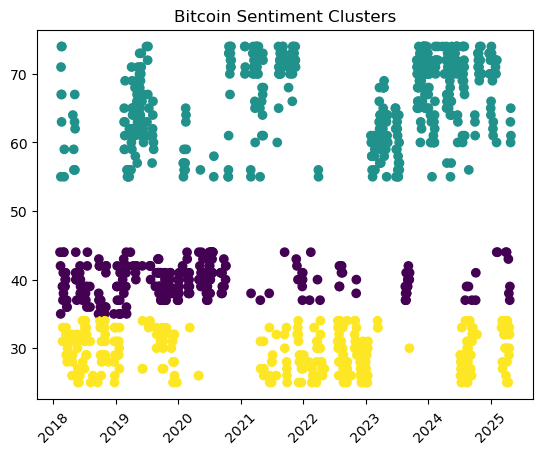

In [19]:
plt.scatter(df_sentiment['date'], df_sentiment['value'], c=df_sentiment['cluster'])
plt.title("Bitcoin Sentiment Clusters")
plt.xticks(rotation=45)
plt.show()


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, mean_squared_error
from sklearn.preprocessing import StandardScaler


In [29]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')


In [30]:
df['sentiment_binary'] = df['classification'].map({
    'Extreme Fear': 0,
    'Fear': 0,
    'Greed': 1,
    'Extreme Greed': 1
})


In [38]:
df['rolling_mean'] = df['value'].rolling(7).mean()
df['rolling_std'] = df['value'].rolling(7).std()


In [39]:
df['next_sentiment'] = df['sentiment_binary'].shift(-1)
df = df.dropna()


In [40]:
X = df[['value', 'sentiment_binary']]
y = df['next_sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96        94
         1.0       0.99      0.99      0.99       326

    accuracy                           0.98       420
   macro avg       0.97      0.97      0.97       420
weighted avg       0.98      0.98      0.98       420



In [41]:
df['volatility'] = df['value'].diff().abs()
df['next_volatility'] = df['volatility'].shift(-1)
df = df.dropna()


In [42]:
X = df[['value', 'sentiment_binary']]
y = df['next_volatility']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

reg = RandomForestRegressor(n_estimators=150, random_state=42)
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))


MSE: 23.727031730038426


In [43]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df[['value']])

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled)

print(df.groupby('cluster')['value'].mean())


cluster
0    39.383817
1    73.243757
2    21.463035
Name: value, dtype: float64


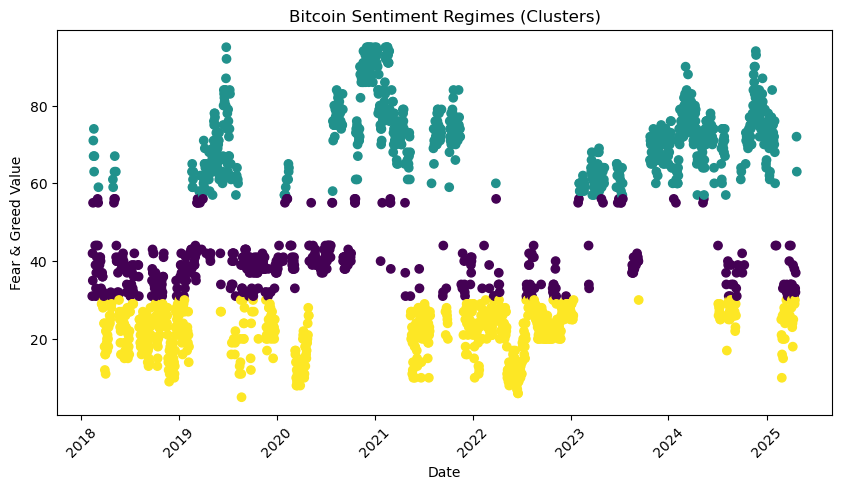

In [44]:
plt.figure(figsize=(10,5))
plt.scatter(df['date'], df['value'], c=df['cluster'])
plt.title("Bitcoin Sentiment Regimes (Clusters)")
plt.xlabel("Date")
plt.ylabel("Fear & Greed Value")
plt.xticks(rotation=45)
plt.show()


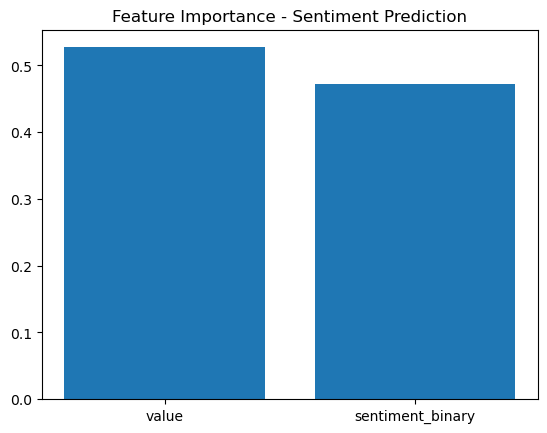

In [45]:
importances = clf.feature_importances_

plt.bar(['value','sentiment_binary'], importances)
plt.title("Feature Importance - Sentiment Prediction")
plt.show()


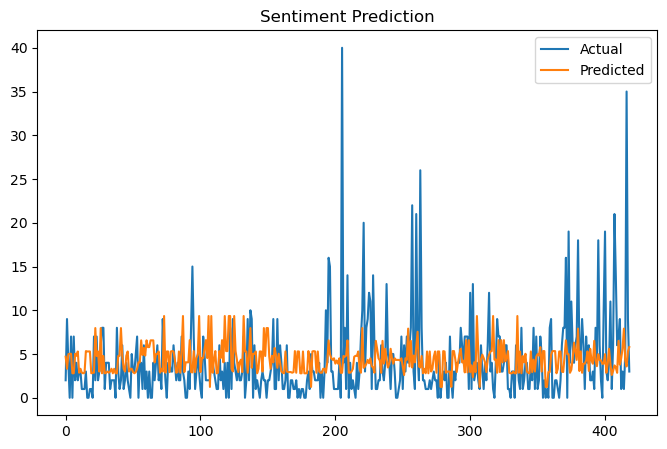

In [50]:
import os
import matplotlib.pyplot as plt

# Create folder
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

# Create plot
plt.figure(figsize=(8,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.title("Sentiment Prediction")
plt.legend()

# Save plot
plt.savefig(os.path.join(output_dir, "sentiment_prediction.png"))

# Show plot
plt.show()

